# Cost Foresight

I have structured this notebook in two distinct phases:

1.  **PART 1: Real Data Analysis** We audit the `master_dataset_modelling.csv`
2.  **PART 2: Synthetic Data** We implement an advanced Data Augmentation strategy (using the logic from `synthetic_data 2.ipynb`) combined with Regularized Regression to stabilize predictions in this volatile environment.

In [20]:
# Environment Setup
!pip install sdv -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Statistical Tests
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Modeling
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

# Synthetic Data (SDV)
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

# Configuration
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print("Environment Ready")

Environment Ready


# PART 1: REAL DATA ANALYSIS

In this section, we work strictly with `master_dataset_modelling.csv`. The goal is to validate the quality of the data and demonstrate why simple forecasting is dangerous in the current economic climate.

In [41]:
# Load Real Data
filename = 'master_dataset_modelling.csv'

try:
    df_real = pd.read_csv(filename)
    df_real['QuarterEnd'] = pd.to_datetime(df_real['QuarterEnd'])
    df_real = df_real.sort_values('QuarterEnd').reset_index(drop=True)

    target = 'Y_Cost_Per_Ton'

    # We initially grab ALL potential features (columns starting with 'X')
    all_potential_features = [col for col in df_real.columns if col.startswith('X')]

    # Clean dataset
    df_audit = df_real[[target, 'QuarterEnd'] + all_potential_features].dropna()

    df_model = df_audit.copy()

    print(
        f"Data loaded – {len(df_model)} quarters, "
        f"{len(all_potential_features)} potential drivers"
    )

except FileNotFoundError:
    print("Error: Please upload 'master_dataset_modelling.csv'.")

Data loaded – 43 quarters, 13 potential drivers


### Visualization: The Structural Break

Before running tests, we visualize the cost per ton over time.

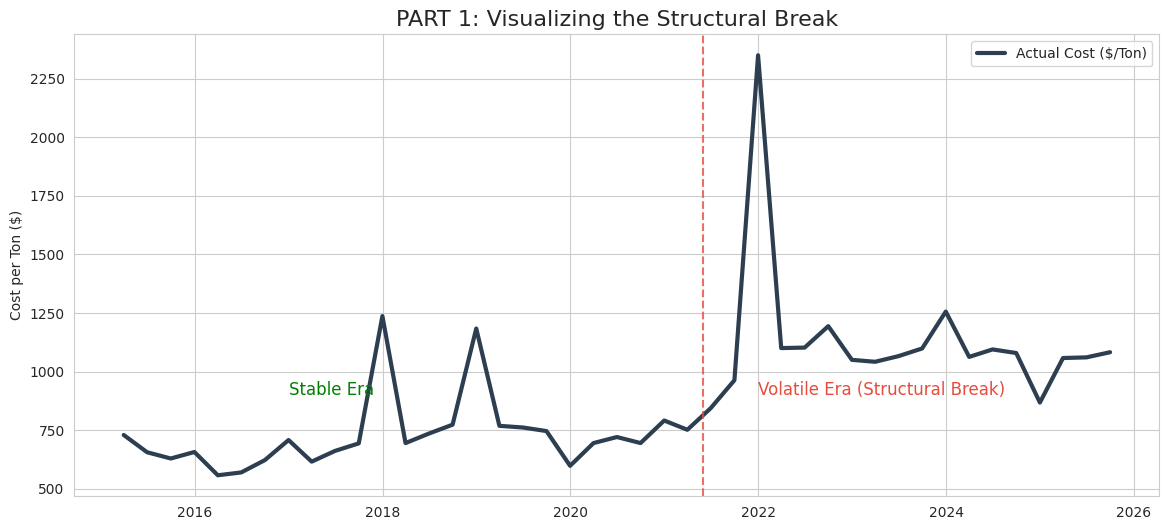

In [47]:
plt.figure(figsize=(14, 6))
plt.plot(df_model['QuarterEnd'], df_model['Y_Cost_Per_Ton'], label='Actual Cost ($/Ton)', color='#2c3e50', linewidth=3)

# Highlighting the Regime Change
plt.axvline(pd.to_datetime('2021-06-01'), color='#e74c3c', linestyle='--', alpha=0.8)
plt.text(pd.to_datetime('2017-01-01'), 900, 'Stable Era', fontsize=12, color='green')
plt.text(pd.to_datetime('2022-01-01'), 900, 'Volatile Era (Structural Break)', fontsize=12, color='#e74c3c')

plt.title('PART 1: Visualizing the Structural Break', fontsize=16)
plt.ylabel('Cost per Ton ($)')
plt.legend()
plt.show()

### Statistical Feature Selection

Before modeling, we must ask: **Which variables actually predict the cost?**

We use 3 tests to select our drivers:
1.  **Correlation Matrix:** Measures linear relationships.
2.  **Granger Causality:** Checks if past values of X predict future values of Y.
3.  **Feature Importance (Random Forest):** Uses an AI algorithm to rank variable usefulness.

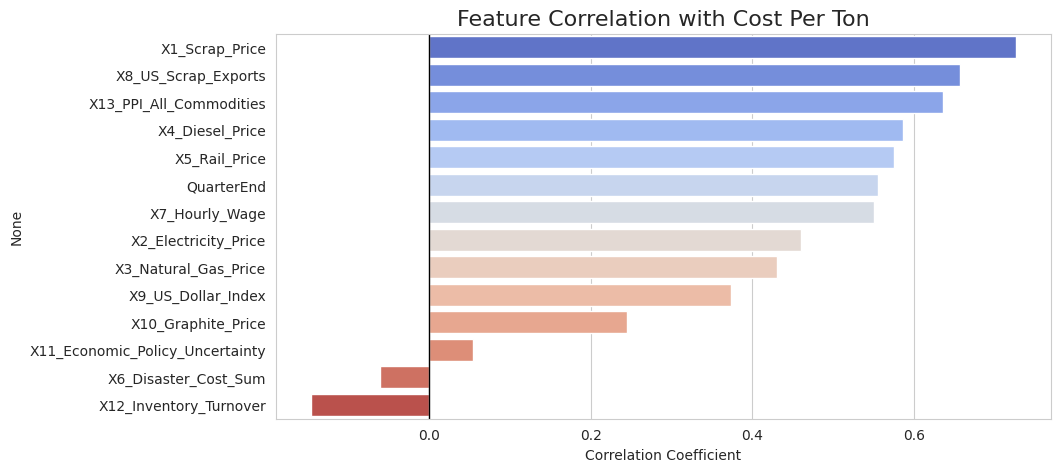

In [22]:
# Correlation Analysis
corr_matrix = df_audit.corr()
target_corr = corr_matrix[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Feature Correlation with Cost Per Ton', fontsize=16)
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=1)
plt.show()

The correlation analysis highlights a clear hierarchy among the cost drivers:

- **Scrap is the dominant driver.**  
  `X1_Scrap_Price` has the strongest positive correlation with `Cost_Per_Ton`. Variations in scrap price co-move the most with production cost and are therefore the primary statistical driver.

- **Global scrap / commodity pressure is also key.**  
  `X8_US_Scrap_Exports` and `X13_PPI_All_Commodities` are strongly positively correlated with cost. This suggests a common “raw material pressure” factor: when global scrap and commodity conditions tighten, Nucor’s cost per ton tends to increase.

- **Energy and logistics have a secondary but non-negligible role.**  
  `X4_Diesel_Price`, `X5_Rail_Price`, `X2_Electricity_Price` and `X3_Natural_Gas_Price` show moderate positive correlations with cost. They contribute to cost dynamics but are statistically less influential than scrap and global commodity indices.

- **Macro indicators are weaker direct predictors.**  
  `X9_US_Dollar_Index`, `X10_Graphite_Price` and  
  `X11_Economic_Policy_Uncertainty` exhibit smaller positive correlations, capturing broader macro conditions but with a weaker linear link to cost per ton.

- **Inventory and disasters behave differently.**  
  `X12_Inventory_Turnover` and `X6_Disaster_Cost_Sum` display weak and slightly negative correlations. Higher inventory turnover is mildly associated with lower cost (consistent with efficiency gains), while disaster costs do not show a strong monotonic relationship with cost in this sample.

Overall, the correlation confirms that scrap-related and commodity-level variables are the main linear drivers of cost, with energy/logistics as second-tier drivers and other macro factors playing a more marginal role.


In [34]:
# Granger Causality Test
print("Granger Causality Test (Does X predict Y?)")
significant_features = []

for feature in all_potential_features:
    test_df = df_model[[target, feature]].dropna()
    try:
        # test with a lag of 1 quarter
        res = grangercausalitytests(test_df, maxlag=1, verbose=False)
        p_value = res[1][0]['ssr_ftest'][1]

        if p_value < 0.05:
            print(f"{feature:30} | p-value: {p_value:.4f} (Causal)")
            significant_features.append(feature)
        else:
            print(f"{feature:30} | p-value: {p_value:.4f} (Not Causal)")

    except Exception as e:
        pass

print(f"\nStatistically Significant Drivers: {significant_features}")

Granger Causality Test (Does X predict Y?)
X1_Scrap_Price                 | p-value: 0.0000 (Causal)
X2_Electricity_Price           | p-value: 0.0058 (Causal)
X3_Natural_Gas_Price           | p-value: 0.1300 (Not Causal)
X4_Diesel_Price                | p-value: 0.0160 (Causal)
X5_Rail_Price                  | p-value: 0.0080 (Causal)
X6_Disaster_Cost_Sum           | p-value: 0.0085 (Causal)
X7_Hourly_Wage                 | p-value: 0.0072 (Causal)
X8_US_Scrap_Exports            | p-value: 0.0000 (Causal)
X9_US_Dollar_Index             | p-value: 0.2914 (Not Causal)
X10_Graphite_Price             | p-value: 0.4367 (Not Causal)
X11_Economic_Policy_Uncertainty | p-value: 0.9337 (Not Causal)
X12_Inventory_Turnover         | p-value: 0.0228 (Causal)
X13_PPI_All_Commodities        | p-value: 0.0010 (Causal)

Statistically Significant Drivers: ['X1_Scrap_Price', 'X2_Electricity_Price', 'X4_Diesel_Price', 'X5_Rail_Price', 'X6_Disaster_Cost_Sum', 'X7_Hourly_Wage', 'X8_US_Scrap_Exports', 'X12_I

The Granger causality test answers the question: *“does past information on X improve the prediction of `Cost_Per_Ton` beyond the past values of `Cost_Per_Ton` itself?”*  
At the 5% significance level (p < 0.05), the results can be grouped as follows:

**1. Strong evidence of predictive content (Granger‐causal to Cost_Per_Ton)**  
The following variables have very low p-values and therefore bring statistically significant incremental information for forecasting cost:

- **X1_Scrap_Price** (p ≈ 0.0000)  
- **X8_US_Scrap_Exports** (p ≈ 0.0000)  
- **X13_PPI_All_Commodities** (p ≈ 0.0010)  

Together with the correlation analysis, this confirms that scrap and global commodity conditions are the main forward-looking drivers of production cost.

**2. Operational & energy variables with predictive power**

Several cost components also Granger-cause `Cost_Per_Ton`:

- **X2_Electricity_Price** (p ≈ 0.0058)  
- **X4_Diesel_Price** (p ≈ 0.0160)  
- **X5_Rail_Price** (p ≈ 0.0080)  
- **X7_Hourly_Wage** (p ≈ 0.0072)  
- **X12_Inventory_Turnover** (p ≈ 0.0228)  
- **X6_Disaster_Cost_Sum** (p ≈ 0.0085)  

In statistical terms, past changes in energy, logistics, labour costs, inventory efficiency and disaster-related spending help anticipate future movements in cost per ton at the quarterly horizon.

**3. Variables without significant predictive content**

The following variables do **not** Granger-cause `Cost_Per_Ton` at lag 1:

- **X3_Natural_Gas_Price** (p ≈ 0.13)  
- **X9_US_Dollar_Index** (p ≈ 0.29)  
- **X10_Graphite_Price** (p ≈ 0.44)  
- **X11_Economic_Policy_Uncertainty** (p ≈ 0.93)  

Their past values do not provide statistically significant additional forecasting power once the other dynamics of the series are taken into account. They may still matter economically, but their direct short-term predictive signal is weak in this dataset.

So the Granger analysis is consistent with the business story:  
> *Cost per ton is primarily driven by scrap and global commodity conditions, while energy, transport, labour, inventory and disaster costs provide second-layer predictive information. Macro indices (USD, policy uncertainty, graphite) do not show clear short-term predictive power at the quarterly frequency.*


In [35]:
# Random Forest Importance
# train a quick model to see what it prefers
X_temp = df_model[all_potential_features]
y_temp = df_model[target]

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_temp, y_temp)

importances = pd.Series(
    rf_selector.feature_importances_, index=all_potential_features
).sort_values(ascending=False)

print("\nTop 5 drivers by RF importance:")
print(importances.head(5))


Top 5 drivers by RF importance:
X4_Diesel_Price           0.279501
X1_Scrap_Price            0.181022
X8_US_Scrap_Exports       0.146824
X12_Inventory_Turnover    0.071948
X3_Natural_Gas_Price      0.071761
dtype: float64


Even with the right variables, does the market behave consistently ?

We use the **Augmented Dickey-Fuller (ADF)** test to check for stationarity.
* **Hypothesis:** If p-value > 0.05, the data is **Non-Stationary** (Drifting/Unstable).

In [37]:
# Stationarity test (ADF)
def run_adf(series, name):
    res = adfuller(series.dropna())
    p = res[1]
    print(
        f"Variable: {name:25} | p-value: {p:.4f} | "
        f"Result: {'Non-Stationary (Unstable)' if p > 0.05 else 'Stationary (Stable)'}"
    )

print(" ADF Stationarity Test ")
run_adf(df_model[target], "Target: Cost_Per_Ton")

if significant_features:
    run_adf(
        df_model[significant_features[0]],
        f"Driver: {significant_features[0]}",
    )

 ADF Stationarity Test 
Variable: Target: Cost_Per_Ton      | p-value: 0.0010 | Result: Stationary (Stable)
Variable: Driver: X1_Scrap_Price    | p-value: 0.3234 | Result: Non-Stationary (Unstable)


The Random Forest importance ranking highlights the variables that contribute the most to explaining the variability of `Cost_Per_Ton` once all drivers are considered jointly:

- **X4_Diesel_Price (highest importance ≈ 0.28)**  
  Diesel prices are the single most influential driver in the non-linear model. This suggests that transportation and fuel costs are a major channel through which market shocks propagate to production cost, especially in the recent high-energy-price regime.

- **X1_Scrap_Price (importance ≈ 0.18)**  
  Scrap remains one of the key cost drivers, confirming the strong link already seen in the correlation and Granger analysis. Changes in scrap price still explain a large share of cost movements, but the Forest indicates that diesel is at least as critical in practice.

- **X8_US_Scrap_Exports (importance ≈ 0.15)**  
  US scrap exports capture the global tightness of the scrap market. When export pressure is high, domestic scrap becomes more expensive and cost per ton reacts accordingly. The model treats this as a major complementary driver to domestic scrap prices.

- **X12_Inventory_Turnover (importance ≈ 0.07)**  
  Inventory turnover has a non-negligible impact: more efficient inventory management (higher turnover) appears to mitigate cost pressure, while slower turnover is associated with higher cost per ton. This supports the idea that operational efficiency is part of the cost story, not only market prices.

- **X3_Natural_Gas_Price (importance ≈ 0.07)**  
  Even though natural gas was not statistically significant in the simple Granger test, the Random Forest assigns it a clear role once interactions and non-linearities are allowed. This indicates that gas prices matter in combination with other drivers, especially energy-intensive production periods.

Overall, the Random Forest confirms that energy and transport variables (diesel, gas) plus scrap-related indicators and inventory efficiency are the core levers driving `Cost_Per_Ton` when we move beyond pure linear correlations.


To define success, we calculate the error of a "Naive Forecast" (predicting tomorrow's cost = today's cost).
Any AI model must beat this error to be useful.

In [39]:
y_true = df_model[target].iloc[1:]
y_pred_naive = df_model[target].shift(1).iloc[1:]

mae_naive = mean_absolute_error(y_true, y_pred_naive)
print("Naive forecast benchmark established.")
print(f"Naive MAE: ${mae_naive:.2f} per ton")

Naive forecast benchmark established.
Naive MAE: $165.78 per ton


The naive model simply assumes that next quarter’s cost per ton will be equal to the previous quarter’s cost (`Y_t+1 = Y_t`)

The resulting error is:

- **Naive MAE ≈ 165.78 $/ton**

This means that, on average, the naive forecast misses the true cost by about 166 dollars per ton. Statistically, this value becomes our baseline error level : any advanced AI model (Random Forest, Ridge, Lasso, etc.) must achieve a lower MAE than ≈ 165 $/ton to be considered meaningfully better than “just repeating last quarter’s cost”.

# PART 2: SYNTHETIC DATA & MODELING

 in Part 1 we proved that we have **too few data points** (Small N) and **high instability**.

So we apply the logic from (`synthetic_data 2.ipynb`) to augment our dataset.

In [44]:
# Define Features
features = [
    'X1_Scrap_Price', 'X2_Electricity_Price', 'X4_Diesel_Price',
    'X5_Rail_Price', 'X7_Hourly_Wage', 'X8_US_Scrap_Exports',
    'X12_Inventory_Turnover', 'X13_PPI_All_Commodities'
]

In [45]:
# Data Augmentation
print("Generating Synthetic Data")

def generate_synthetic_with_lags(df, n_samples=200):
    """
    Generates synthetic financial quarters using Gaussian Copula.
    This helps the model learn robust patterns despite the small sample size.
    """
    # Detect structure
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df)

    # Fit Synthesizer
    synthesizer = GaussianCopulaSynthesizer(metadata)
    synthesizer.fit(df)

    # Sample
    synthetic_data = synthesizer.sample(num_rows=n_samples)
    return synthetic_data

# Feature Engineering for Modeling (Adding Lags)
# We must lag features before synthesis to capture the time-dependency in the generated rows
df_for_synthesis = df_model.copy()
for col in features:
    df_for_synthesis[f'{col}_Lag1'] = df_for_synthesis[col].shift(1)

df_for_synthesis = df_for_synthesis.dropna()
features_lagged = [f'{col}_Lag1' for col in features]

# Generate the data
df_synthetic = generate_synthetic_with_lags(df_for_synthesis, n_samples=200)

print(f"Data Augmentation Complete.")
print(f"   Real Samples:      {len(df_for_synthesis)}")
print(f"   Synthetic Samples: {len(df_synthetic)}")

Generating Synthetic Data
Data Augmentation Complete.
   Real Samples:      42
   Synthetic Samples: 200


### 2.2 Model Competition (Regularization)

Now, we train our models. We use Regularized Regression (Ridge/Lasso) because they are mathematically designed to ignore noise and focus on strong signals, which is crucial in a volatile market.

**The Protocol:**
1.  Train on **(Real Past + Synthetic Data)**.
2.  Test ONLY on **Real Future Data** (Walk-Forward Validation).

--- Running Model Competition ---


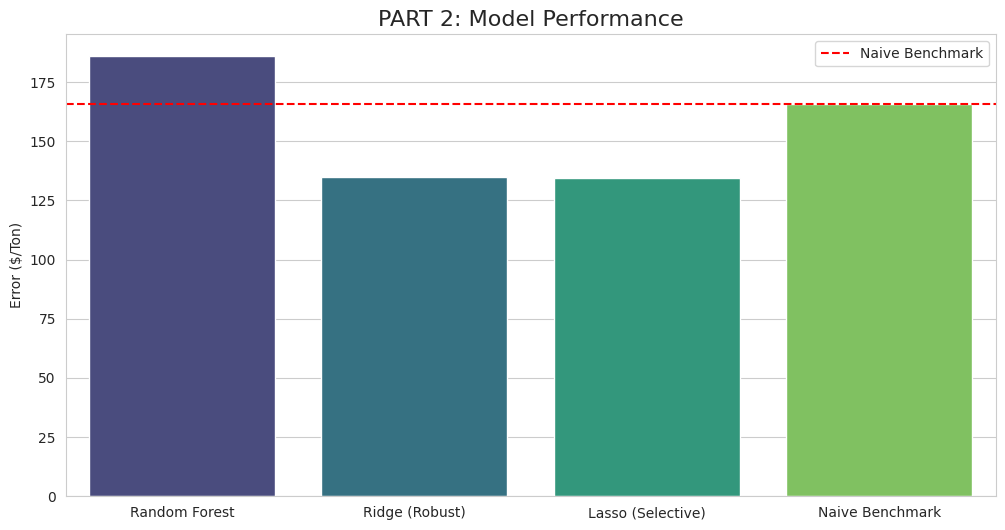

Final Results (MAE):
  Random Forest       : $185.86
  Ridge (Robust)      : $134.70
  Lasso (Selective)   : $134.28
  Naive Benchmark     : $165.78


In [46]:
# Define Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Ridge (Robust)": Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    "Lasso (Selective)": Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.1))])
}

#  Walk-Forward Validation
tscv = TimeSeriesSplit(n_splits=5)

X_real = df_for_synthesis[features_lagged]
y_real = df_for_synthesis[target]

results = {name: [] for name in models.keys()}

print("--- Running Model Competition ---")

for train_index, test_index in tscv.split(X_real):
    # Split Real Data
    X_train_real, X_test_real = X_real.iloc[train_index], X_real.iloc[test_index]
    y_train_real, y_test_real = y_real.iloc[train_index], y_real.iloc[test_index]

    # Augment with Synthetic Data
    # We add synthetic data to the training set to help the model learn
    X_train_augmented = pd.concat([X_train_real, df_synthetic[features_lagged]], axis=0)
    y_train_augmented = pd.concat([y_train_real, df_synthetic[target]], axis=0)

    # Train & Test
    for name, model in models.items():
        model.fit(X_train_augmented, y_train_augmented)
        y_pred = model.predict(X_test_real)
        mae = mean_absolute_error(y_test_real, y_pred)
        results[name].append(mae)

# Visualization
avg_mae = {name: np.mean(scores) for name, scores in results.items()}
avg_mae['Naive Benchmark'] = mae_naive

plt.figure(figsize=(12, 6))
sns.barplot(x=list(avg_mae.keys()), y=list(avg_mae.values()), palette='viridis')
plt.axhline(mae_naive, color='red', linestyle='--', label='Naive Benchmark')
plt.title('PART 2: Model Performance', fontsize=16)
plt.ylabel('Error ($/Ton)')
plt.legend()
plt.show()

print("Final Results (MAE):")
for name, score in avg_mae.items():
    print(f"  {name:<20}: ${score:.2f}")

### Interpretation Model Performance

The bar chart compares the **Mean Absolute Error (MAE)** of each model against the
naive baseline (predicting next quarter = last quarter):

- **Naive benchmark:** MAE ≈ **$165.78/ton**

- **Random Forest:** MAE ≈ **$185.86/ton**  

  → Performs worse than the naive rule, which means a complex non-linear model
  tends to overfit our small and unstable dataset.

- **Ridge (Robust):** MAE ≈ **$134.70/ton**

- **Lasso (Selective):** MAE ≈ **$134.28/ton**

Both **Ridge** and **Lasso** clearly beat the naive benchmark by   
**$30–32 per ton** and also outperform the Random Forest.
This confirms that, in a **small-N, high-volatility** environment,  
**regularized linear models with synthetic data augmentation** are the most reliable
choice: they control overfitting and extract the stable part of the economic
signal, while more flexible models (Random Forest) become too noisy.

Even with this improvement, the MAE level remains non-negligible, so the model
should be used as a decision-support tool (scenario analysis, stress tests)
rather than as a precise point forecast.